# NG-DRI-EAF CCS steel NPV simulation

Run the Monte Carlo simulation for the NG-DRI-EAF CCS steel retrofit and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "ng_dri_eaf_ccs"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,bau_variable_opex_eur_per_tcs,bau_fuel_consumption_mwh_th_per_tcs,bau_electricity_consumption_mwh_per_tcs,bau_emissions_tco2_per_tcs,capex_change_eur_per_tcs,fixed_opex_change_eur_per_tcs,variable_opex_change_eur_per_tcs,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction
0,0,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,858.838740,44.3,313.452170,natural_gas,...,312.0,2.606980,1.06,0.648228,200.0,11.8,1.452170,0.0,-0.283019,0.64
1,1,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,858.571719,44.3,313.403238,natural_gas,...,312.0,2.692693,1.06,0.823909,200.0,11.8,1.403238,0.0,-0.283019,0.64
2,2,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,858.329203,44.3,313.416951,natural_gas,...,312.0,2.583159,1.06,0.591700,200.0,11.8,1.416951,0.0,-0.283019,0.64
3,3,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,853.757056,44.3,313.387680,natural_gas,...,312.0,2.517915,1.06,0.636571,200.0,11.8,1.387680,0.0,-0.283019,0.64
4,4,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,853.332984,44.3,313.418566,natural_gas,...,312.0,2.689017,1.06,0.691154,200.0,11.8,1.418566,0.0,-0.283019,0.64


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,104.437109,739.362850,10.637150
std,500.658302,50.993154,50.993154
min,-1761.276107,594.709045,-179.389862
5%,-751.758229,658.092149,-76.568236
50%,120.001869,737.777545,12.222455
95%,902.364825,826.568236,91.907851
max,1524.669486,929.389862,155.290955


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),59051,0.59051
1,Negative (NPV < 0),40949,0.40949


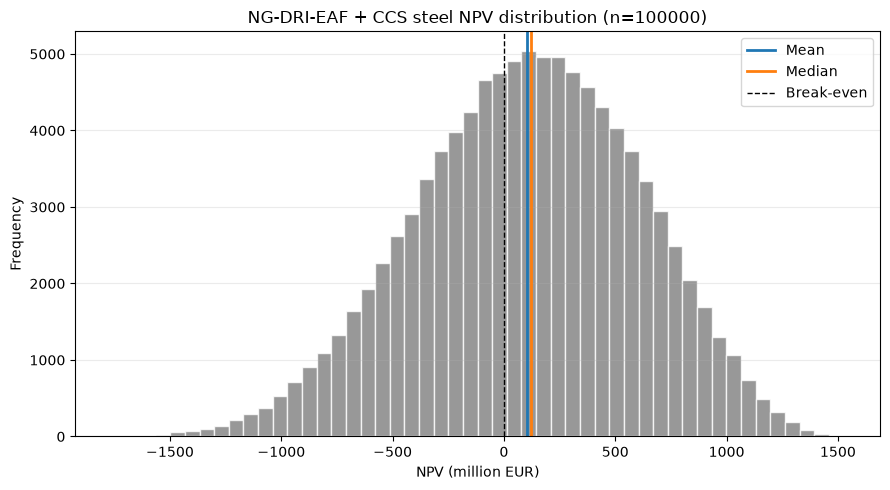

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"NG-DRI-EAF + CCS steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


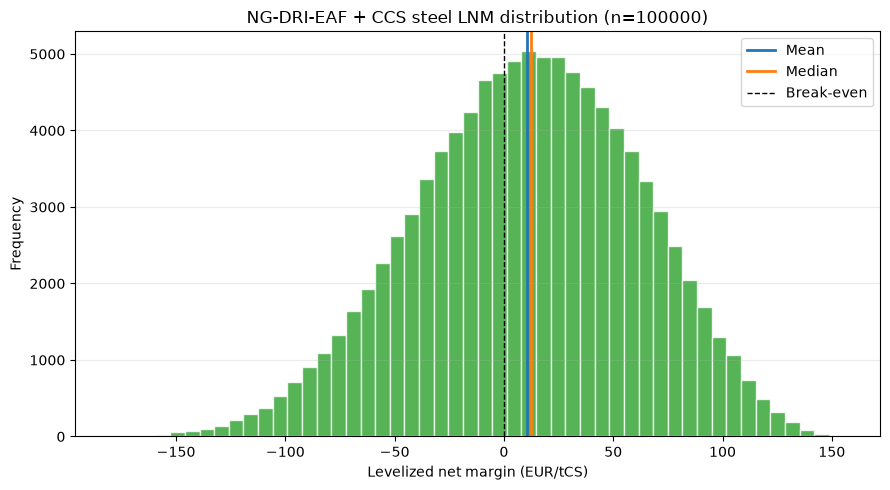

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"NG-DRI-EAF + CCS steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


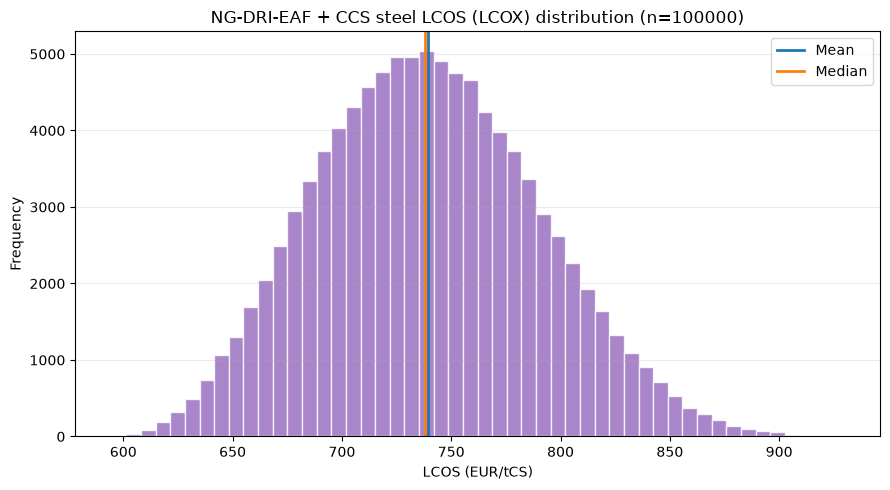

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"NG-DRI-EAF + CCS steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_transport_and_storage_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur                       750.000000
annual_fixed_opex_eur                     44.300000
annual_variable_opex_eur                 313.400200
annual_fuel_cost_eur                     102.514493
annual_electricity_cost_eur              158.543556
annual_transport_and_storage_cost_eur     12.817632
annual_emissions_cost_eur                 20.533231
annual_net_cash_flow_eur                  97.890889
Name: Mean annual value, million EUR, dtype: float64

In [8]:
retrofit_columns = [
    "capex_change_eur_per_tcs",
    "fixed_opex_change_eur_per_tcs",
    "variable_opex_change_eur_per_tcs",
    "fuel_consumption_reduction_fraction",
    "electricity_consumption_reduction_fraction",
    "emissions_reduction_fraction",
    "bau_capex_eur_per_tcs",
    "bau_fixed_opex_eur_per_tcs",
    "bau_variable_opex_eur_per_tcs",
    "bau_fuel_consumption_mwh_th_per_tcs",
    "bau_electricity_consumption_mwh_per_tcs",
    "bau_emissions_tco2_per_tcs",
    "transport_and_storage_share_of_capture_cost",
    "capture_cost_excluding_transport_and_storage_eur_per_tcs",
    "transport_and_storage_cost_eur_per_tcs",
]

available_retrofit_columns = [
    column for column in retrofit_columns if column in results
]
retrofit_summary = results[available_retrofit_columns].describe(
    percentiles=[0.05, 0.5, 0.95]
)
retrofit_summary


,capex_change_eur_per_tcs,fixed_opex_change_eur_per_tcs,variable_opex_change_eur_per_tcs,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction,bau_capex_eur_per_tcs,bau_fixed_opex_eur_per_tcs,bau_variable_opex_eur_per_tcs,bau_fuel_consumption_mwh_th_per_tcs,bau_electricity_consumption_mwh_per_tcs,bau_emissions_tco2_per_tcs,transport_and_storage_share_of_capture_cost,capture_cost_excluding_transport_and_storage_eur_per_tcs,transport_and_storage_cost_eur_per_tcs
count,100000.0,1.000000e+05,100000.000000,100000.0,1.000000e+05,1.000000e+05,100000.000000,100000.0,100000.0,100000.000000,1.000000e+05,100000.000000,1.000000e+05,100000.000000,100000.000000
mean,200.0,1.180000e+01,1.400200,0.0,-2.830189e-01,6.400000e-01,656.670065,32.5,312.0,2.613354,1.060000e+00,0.712959,1.870000e-01,68.543485,12.817632
std,0.0,1.776366e-15,0.070481,0.0,1.110229e-16,1.110229e-16,2.350226,0.0,0.0,0.061330,2.220457e-16,0.101420,2.775571e-17,7.395449,1.382949
min,200.0,1.180000e+01,1.201004,0.0,-2.830189e-01,6.400000e-01,650.034376,32.5,312.0,2.440692,1.060000e+00,0.550867,1.870000e-01,51.956337,9.715835
5%,200.0,1.180000e+01,1.267465,0.0,-2.830189e-01,6.400000e-01,652.260252,32.5,312.0,2.498222,1.060000e+00,0.579893,1.870000e-01,56.497172,10.564971
50%,200.0,1.180000e+01,1.412050,0.0,-2.830189e-01,6.400000e-01,657.064451,32.5,312.0,2.623674,1.060000e+00,0.695958,1.870000e-01,68.552809,12.819375
95%,200.0,1.180000e+01,1.492319,0.0,-2.830189e-01,6.400000e-01,659.744115,32.5,312.0,2.693493,1.060000e+00,0.903963,1.870000e-01,80.623374,15.076571
max,200.0,1.180000e+01,1.500000,0.0,-2.830189e-01,6.400000e-01,659.999911,32.5,312.0,2.700000,1.060000e+00,0.998583,1.870000e-01,85.027125,15.900072
